# Soft clustering

Like HDBSCAN*, PLSCAN can compute soft membership probabilities for each point.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fast_plscan import PLSCAN

plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (2.75, 0.618 * 2.75)

data = np.load("data/clusterable/sources/clusterable_data.npy")

Import the ``all_points_membership_vectors`` function from the ``prediction``
module to compute membership probabilities. The implementation follows the same
ideas as HDBSCAN* soft clustering, except that it uses mutual reachability
distances rather than raw pairwise distances. See [the HDBSCAN*
documentation](https://hdbscan.readthedocs.io/en/latest/soft_clustering_explanation.html)
for additional details.

In [2]:
from fast_plscan.prediction import all_points_membership_vectors

c = PLSCAN(min_samples=2, min_cluster_size=10).fit(data)
memberships = all_points_membership_vectors(c)

Some points are always treated as noise in this implementation. These points
have zero membership values in all columns because they are direct descendants
of the phantom root. We cannot reliably recover where they should attach in the
hierarchy, so they remain noise.

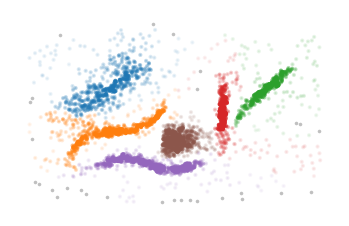

In [3]:
plt.figure()
noise = np.all(memberships == 0, axis=1)
cs = memberships[~noise].argmax(axis=1)
probs = memberships[~noise, cs]
plt.scatter(*data[noise, :].T, s=0.5, color="silver")
plt.scatter(*data[~noise, :].T, s=1, c=cs, alpha=probs, vmax=9, cmap="tab10")
plt.axis("off")
plt.show()

### Precomputed distance inputs

Unlike the HDBSCAN* implementation, we also support computing membership vectors
for precomputed sparse distance matrices. The more neighbors are present, the
more membership information can be extracted. This is visible in the
visualization below as more information in the second and third strongest
memberships.

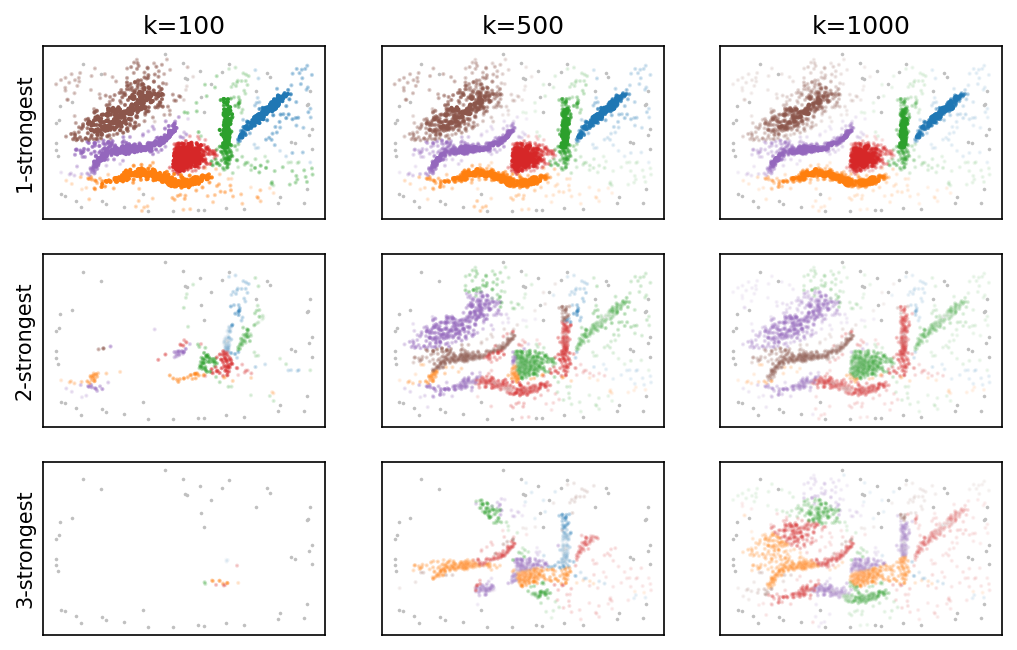

In [4]:
from pynndescent import NNDescent


plt.figure(figsize=(2.75 * 3, 0.618 * 2.75))
plt.gcf().set_size_inches(2.75 * 3, 0.618 * 2.75 * 3)

for i, k in enumerate([100, 500, 1000], 1):
  nn = NNDescent(data, metric="euclidean", n_neighbors=k)
  neighbors, distances = nn.neighbor_graph

  c = PLSCAN(metric="precomputed").fit((distances, neighbors))
  sparse_memberships = all_points_membership_vectors(c)

  noise = np.all(sparse_memberships == 0, axis=1)
  sorted_labels = np.argsort(sparse_memberships, axis=1)[:, ::-1]
  n = sparse_memberships.shape[0]

  for rank in range(3):
    labels = sorted_labels[:, rank]
    alpha = sparse_memberships[np.arange(n), labels]

    plt.subplot(3, 3, rank * 3 + i)
    plt.scatter(*data[noise, :].T, s=0.5, color="silver")
    plt.scatter(
      *data[~noise, :].T,
      s=1,
      c=labels[~noise],
      alpha=alpha[~noise],
      vmax=9,
      cmap="tab10",
    )
    if rank == 0:
      plt.title(f"k={k}")
    if i == 1:
      plt.ylabel(f"{rank + 1}-strongest")
    plt.xticks([])
    plt.yticks([])
plt.show()

## Memberships of unseen points

The ``membership_vectors`` function extends soft clustering to unseen feature
vectors. Each new point is attached to the fitted structure through its nearest
mutual-reachability neighbor in the training set, then both distance-to-exemplar
and topology-based weights are combined in the same way as for training points.
The output has the same semantics as ``all_points_membership_vectors``: each row
sums to at most the point's probability of belonging to any selected cluster.

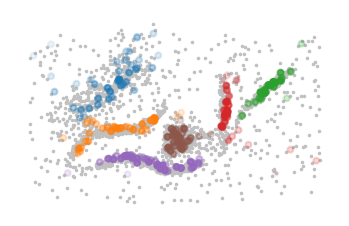

In [10]:
from fast_plscan.prediction import membership_vectors

c = PLSCAN(min_samples=2, min_cluster_size=10).fit(data)

# Use a held-out slice as unseen points
rng = np.random.Generator(np.random.PCG64(25))
X_new = rng.choice(data, size=200, replace=False) + 0.015
mv = membership_vectors(c, X_new)


plt.figure()
noise = np.all(mv == 0, axis=1)
cs = mv[~noise].argmax(axis=1)
probs = mv[~noise, cs]
plt.scatter(*data.T, s=0.5, color="silver", zorder=0)
plt.scatter(*X_new[~noise].T, s=8, c=cs, alpha=probs, vmax=9, cmap="tab10", zorder=1)
plt.axis("off")
plt.show()